In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import parse_slurm as ps
import data_analysis as da
import glob

In [3]:
files = glob.glob('./data/data.*.txt')
data = ps.read_dataset(files)

In [4]:
metric = 'ConsumedEnergy'

# Docking Protein-Protein Energy Analysis 

In [5]:
# get data and remove outliers
dpp_energy = ps.get_data(data, workflow="dpp", column=metric)
dpp_energy = ps.remove_outliers_cpus(dpp_energy, column=metric)

## Boxplots

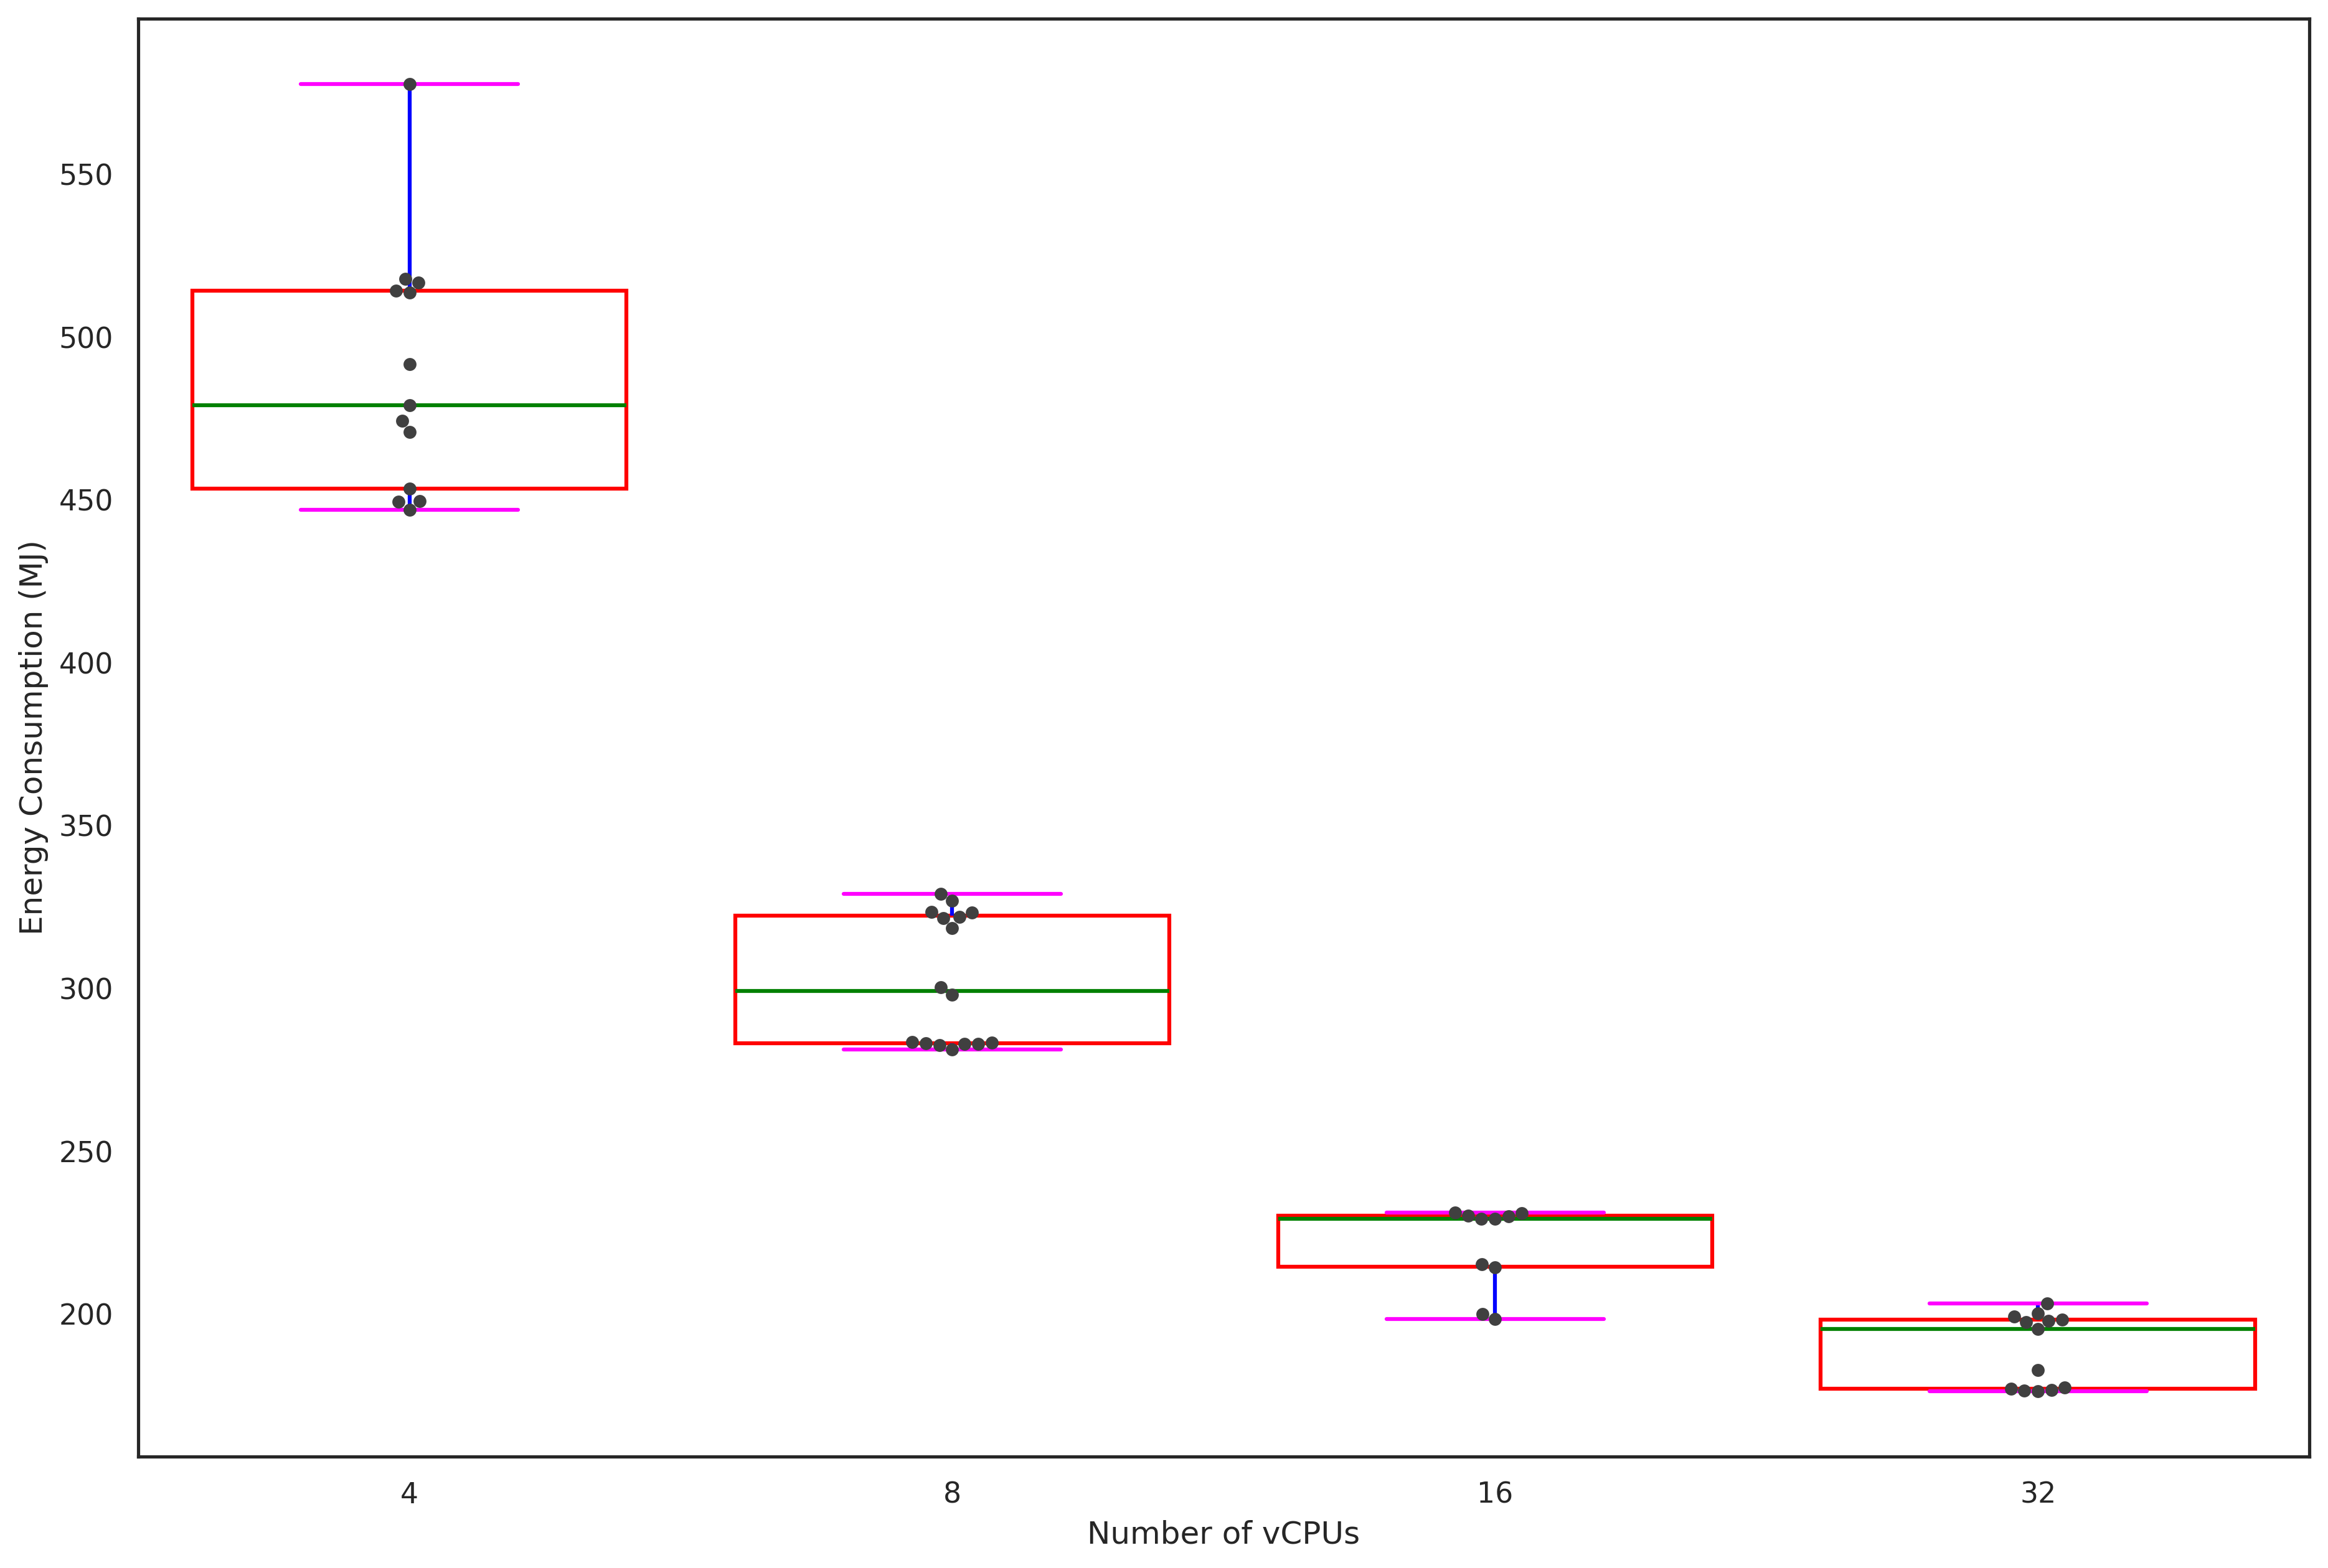

In [6]:
da.show_boxplot(
    dpp_energy, "Energy Consumption of DPP Workflow at Varying Parallelism Degrees",
    x_label="Number of vCPUs", y_label="Energy Consumption (MJ)", store=True
)

## Normality Test: Shapiro-Wilk and QQ-Plots

In [7]:
normality = ps.test_normality(dpp_energy)
print(normality)

   NCPUS      STAT        PVALUE
0      4  0.704019  6.020765e-06
1      8  0.689080  5.993035e-07
2     16  0.681227  2.321830e-05
3     32  0.690861  3.985300e-06


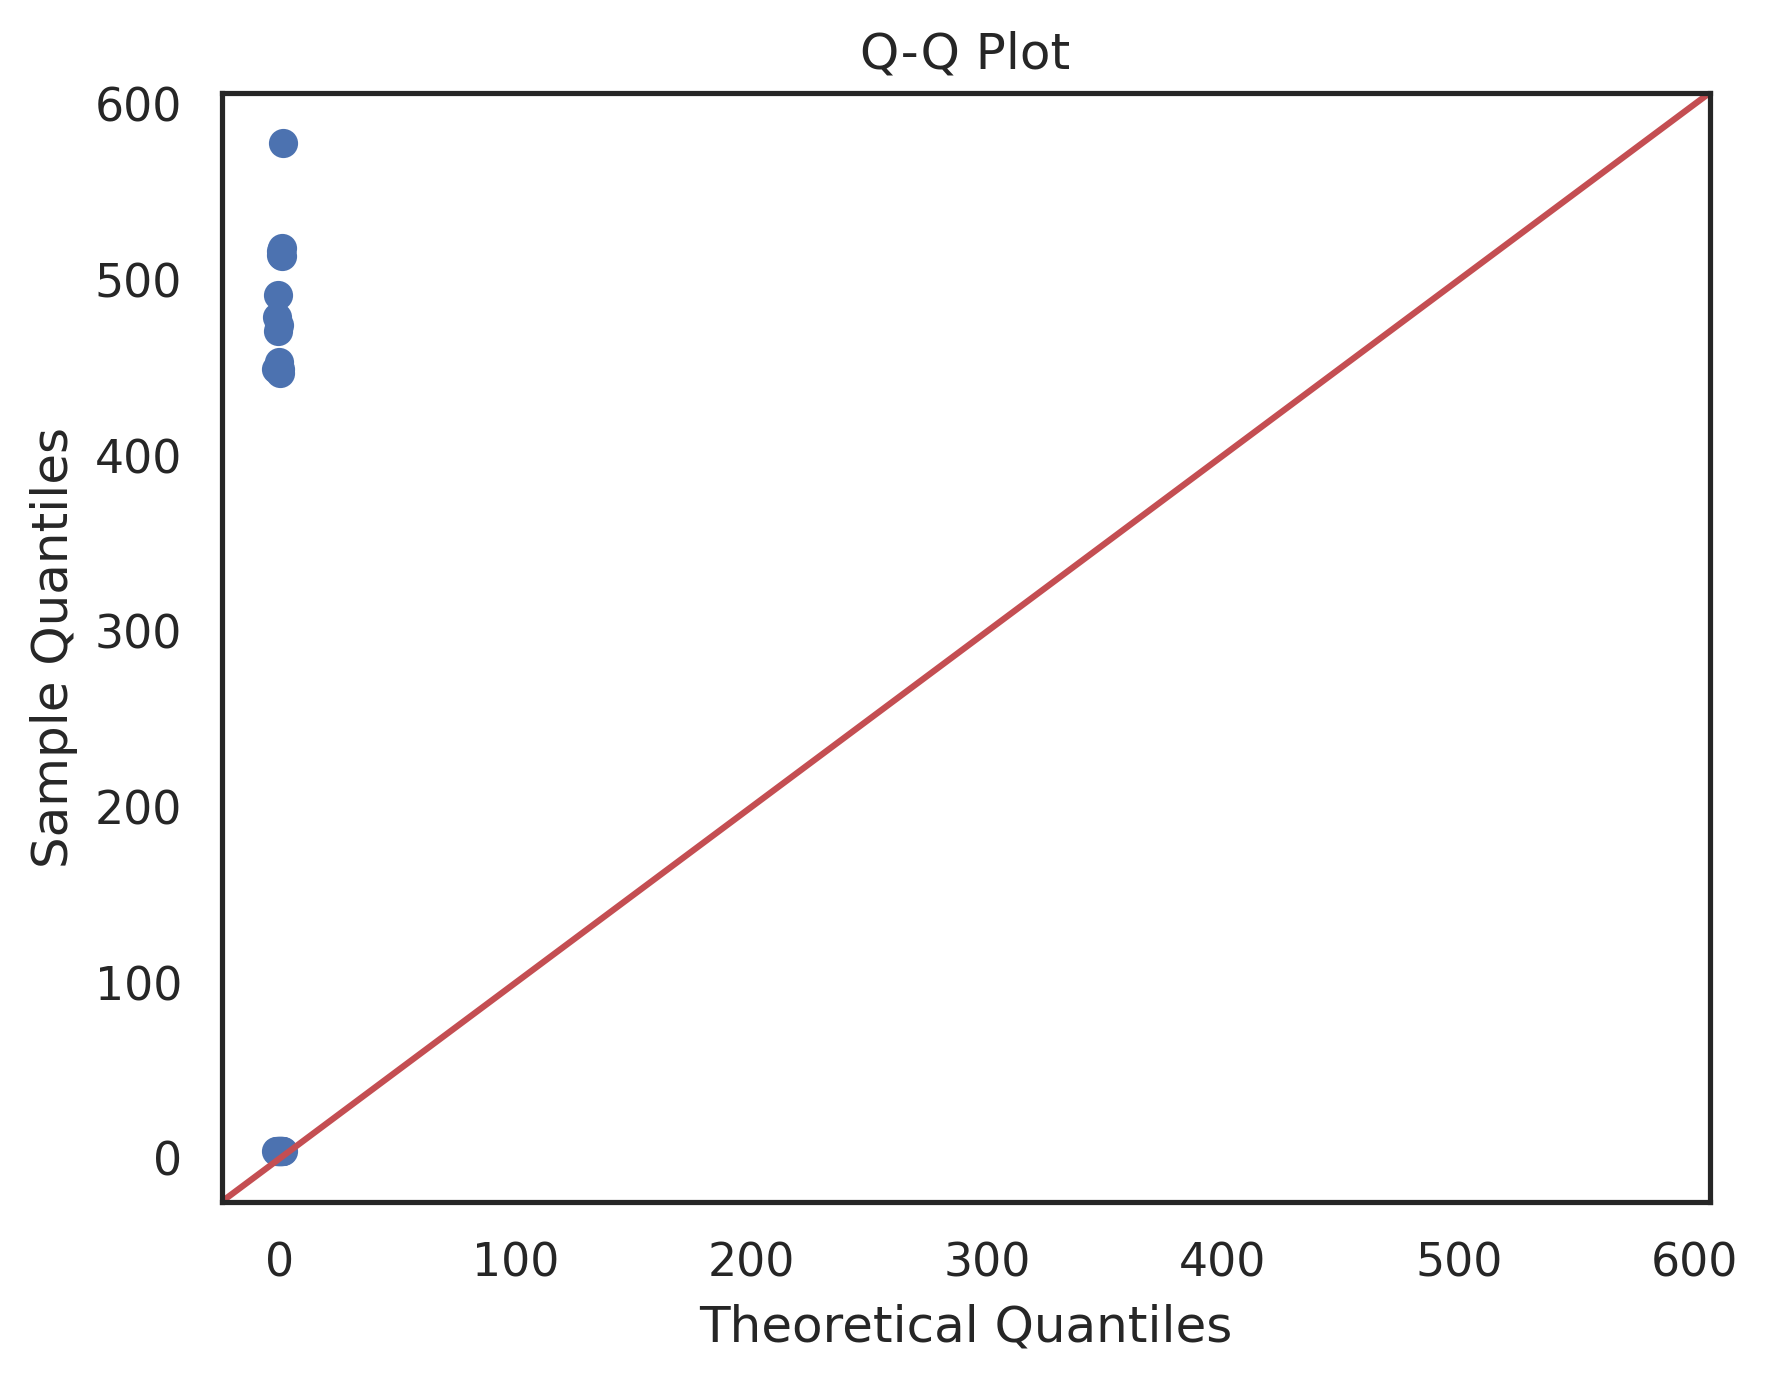

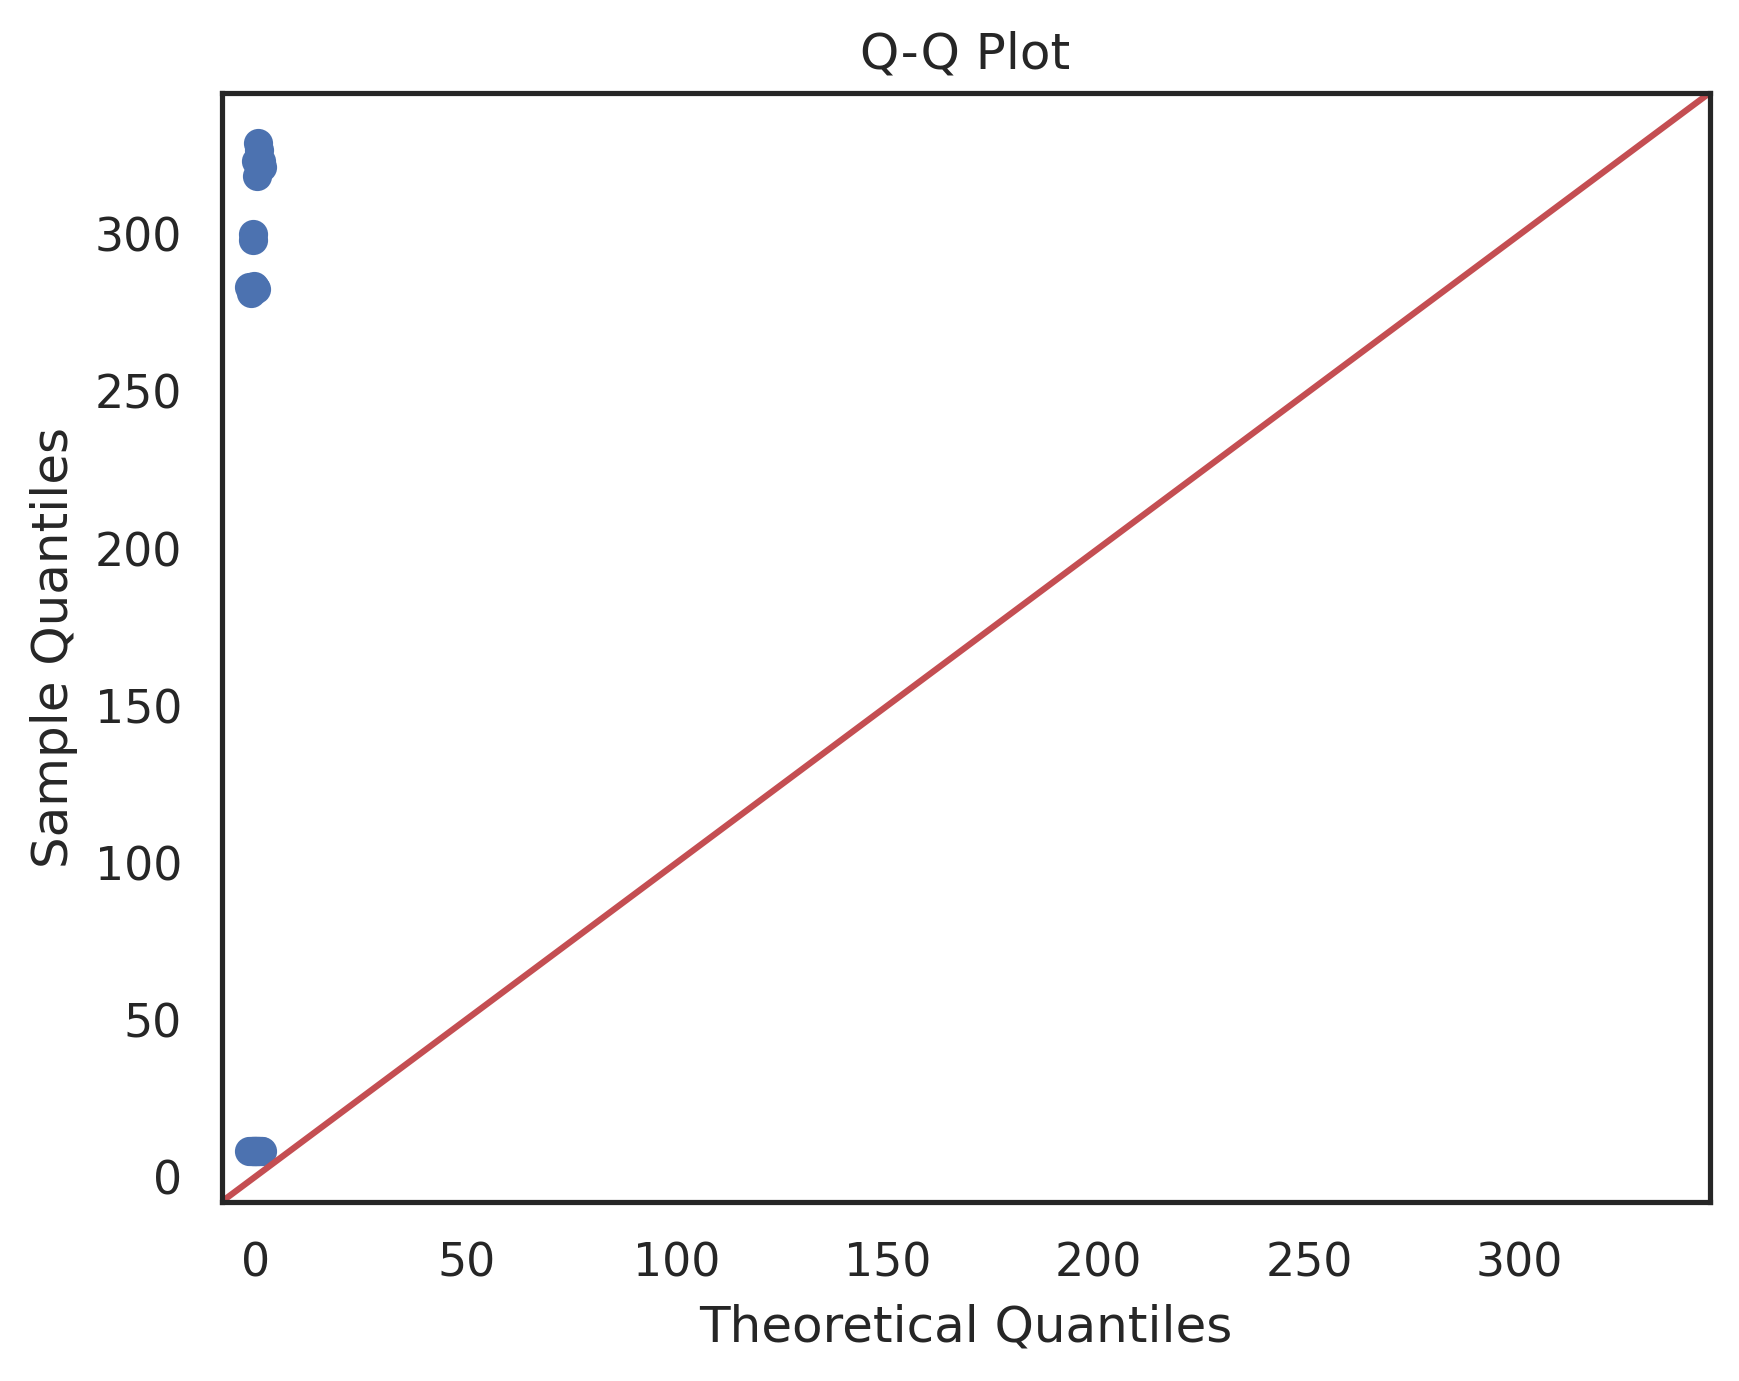

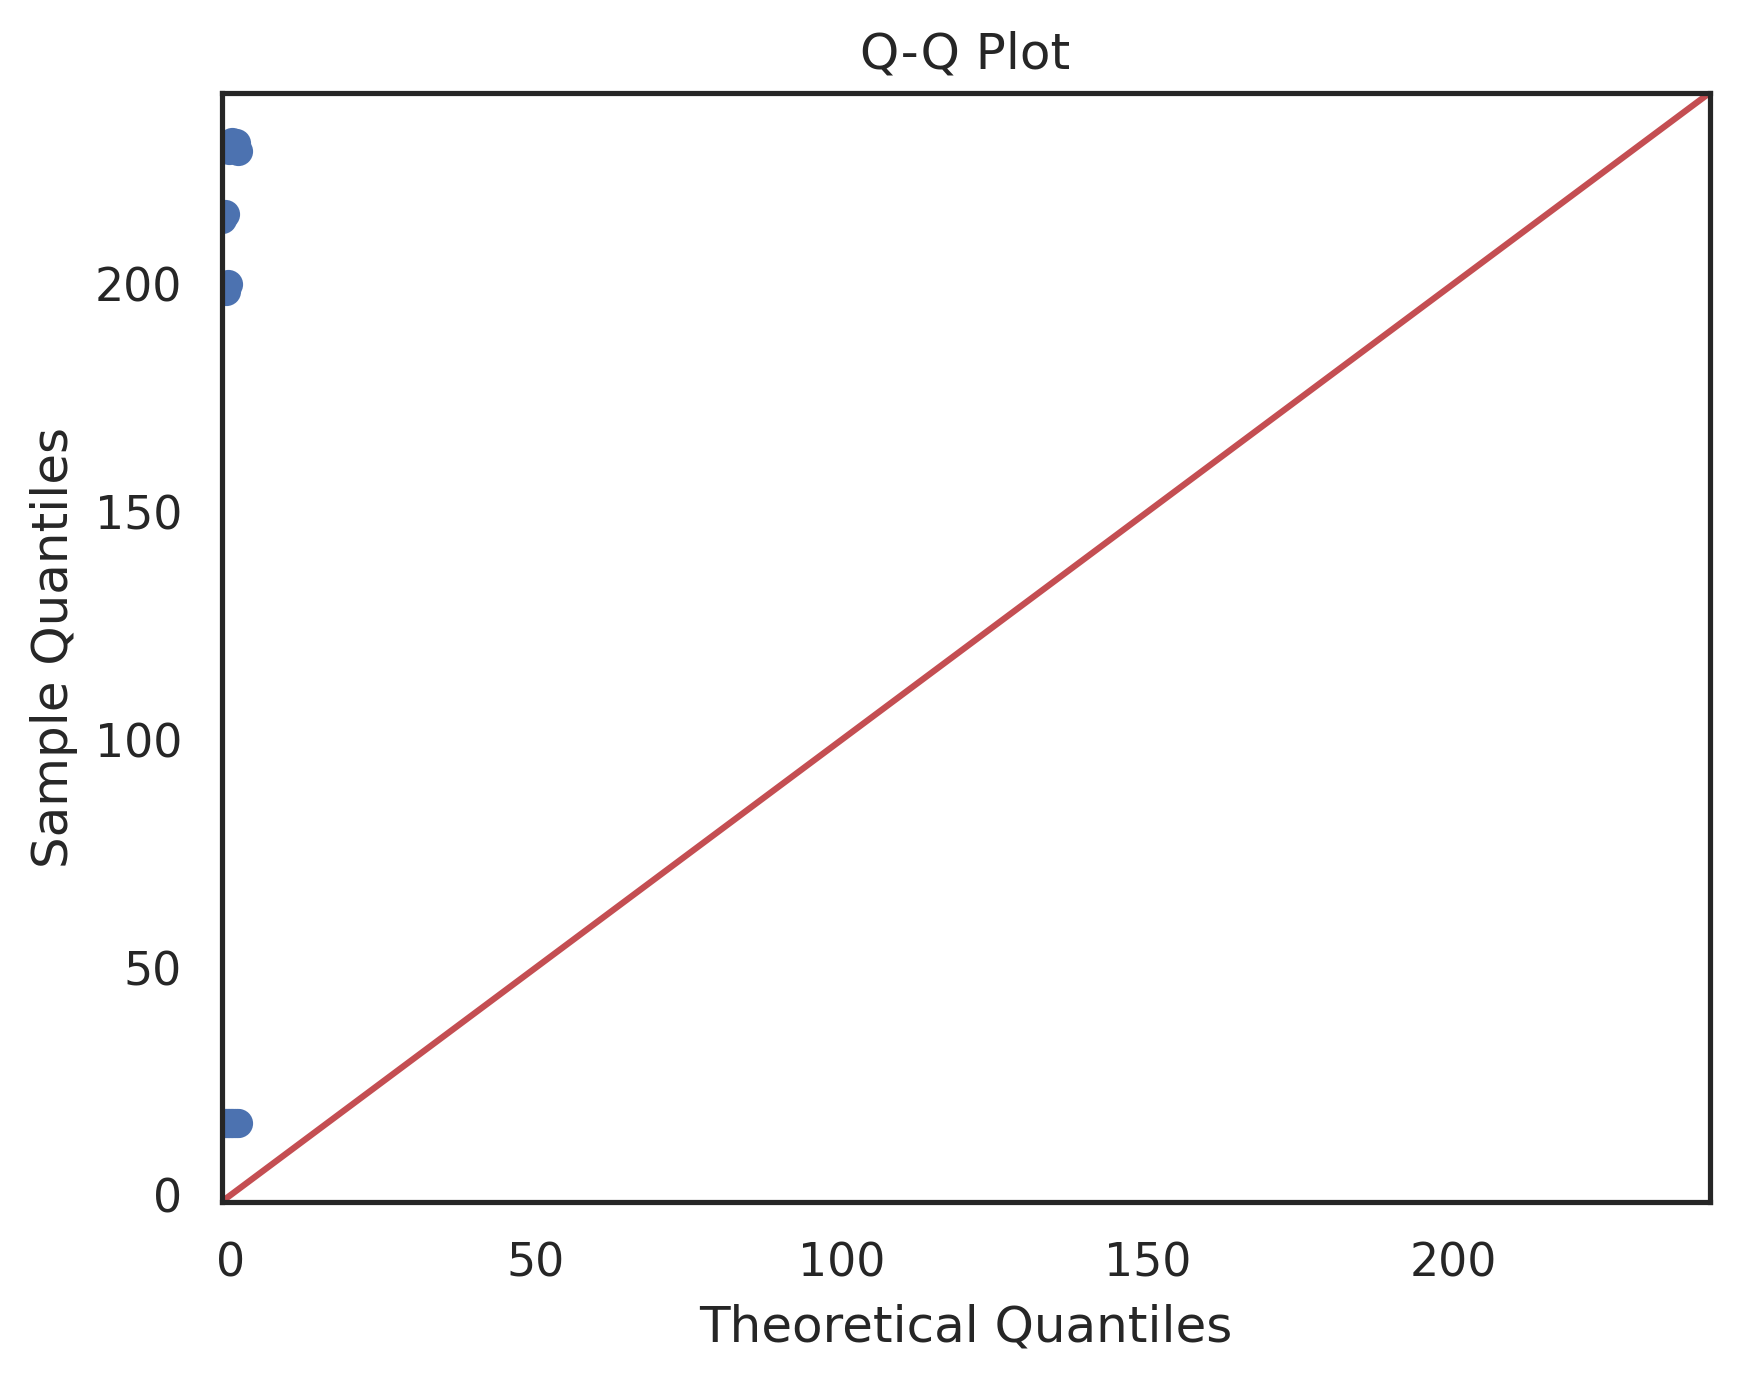

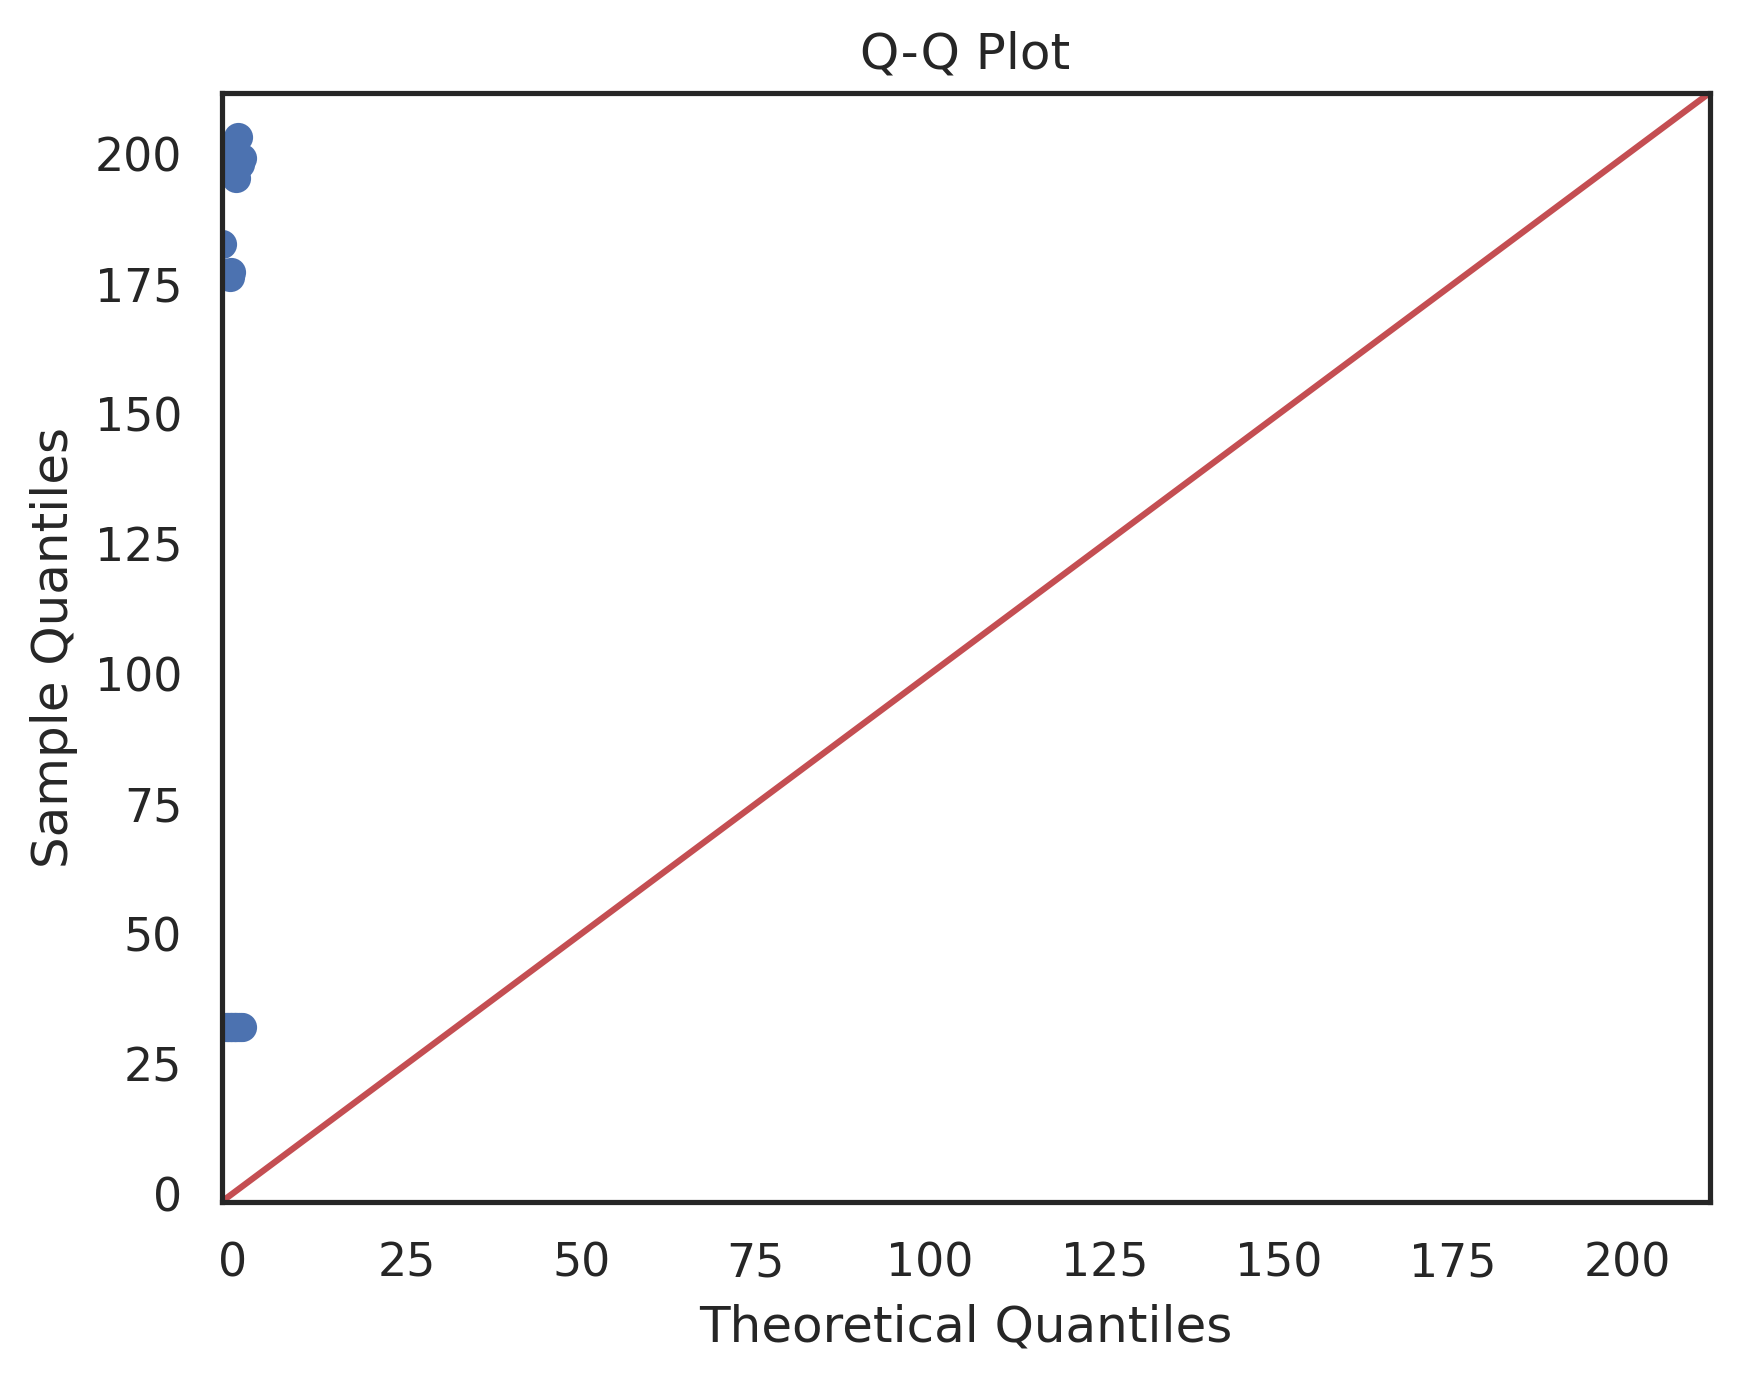

In [8]:
ps.generate_qq(dpp_energy)

## Hypothesis Testing: Kruskal-Wallis

In [9]:
ps.test_hypothesis_kruskal(dpp_energy)

(47.094004689070005, 3.3192067444783175e-10)

## Effect Size: Cliff's Delta

In [23]:
ps.calc_cliffs_delta(dpp_energy)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",1.000000,large
1,"(8, 16)",1.000000,large
2,"(16, 32)",0.923077,large


# Docking Antibody-Antigen Energy Analysis 

In [24]:
# get data and remove outliers
daa_energy = ps.get_data(data, workflow="daa", column=metric)
daa_energy = ps.remove_outliers_cpus(daa_energy, column=metric)

## Boxplots

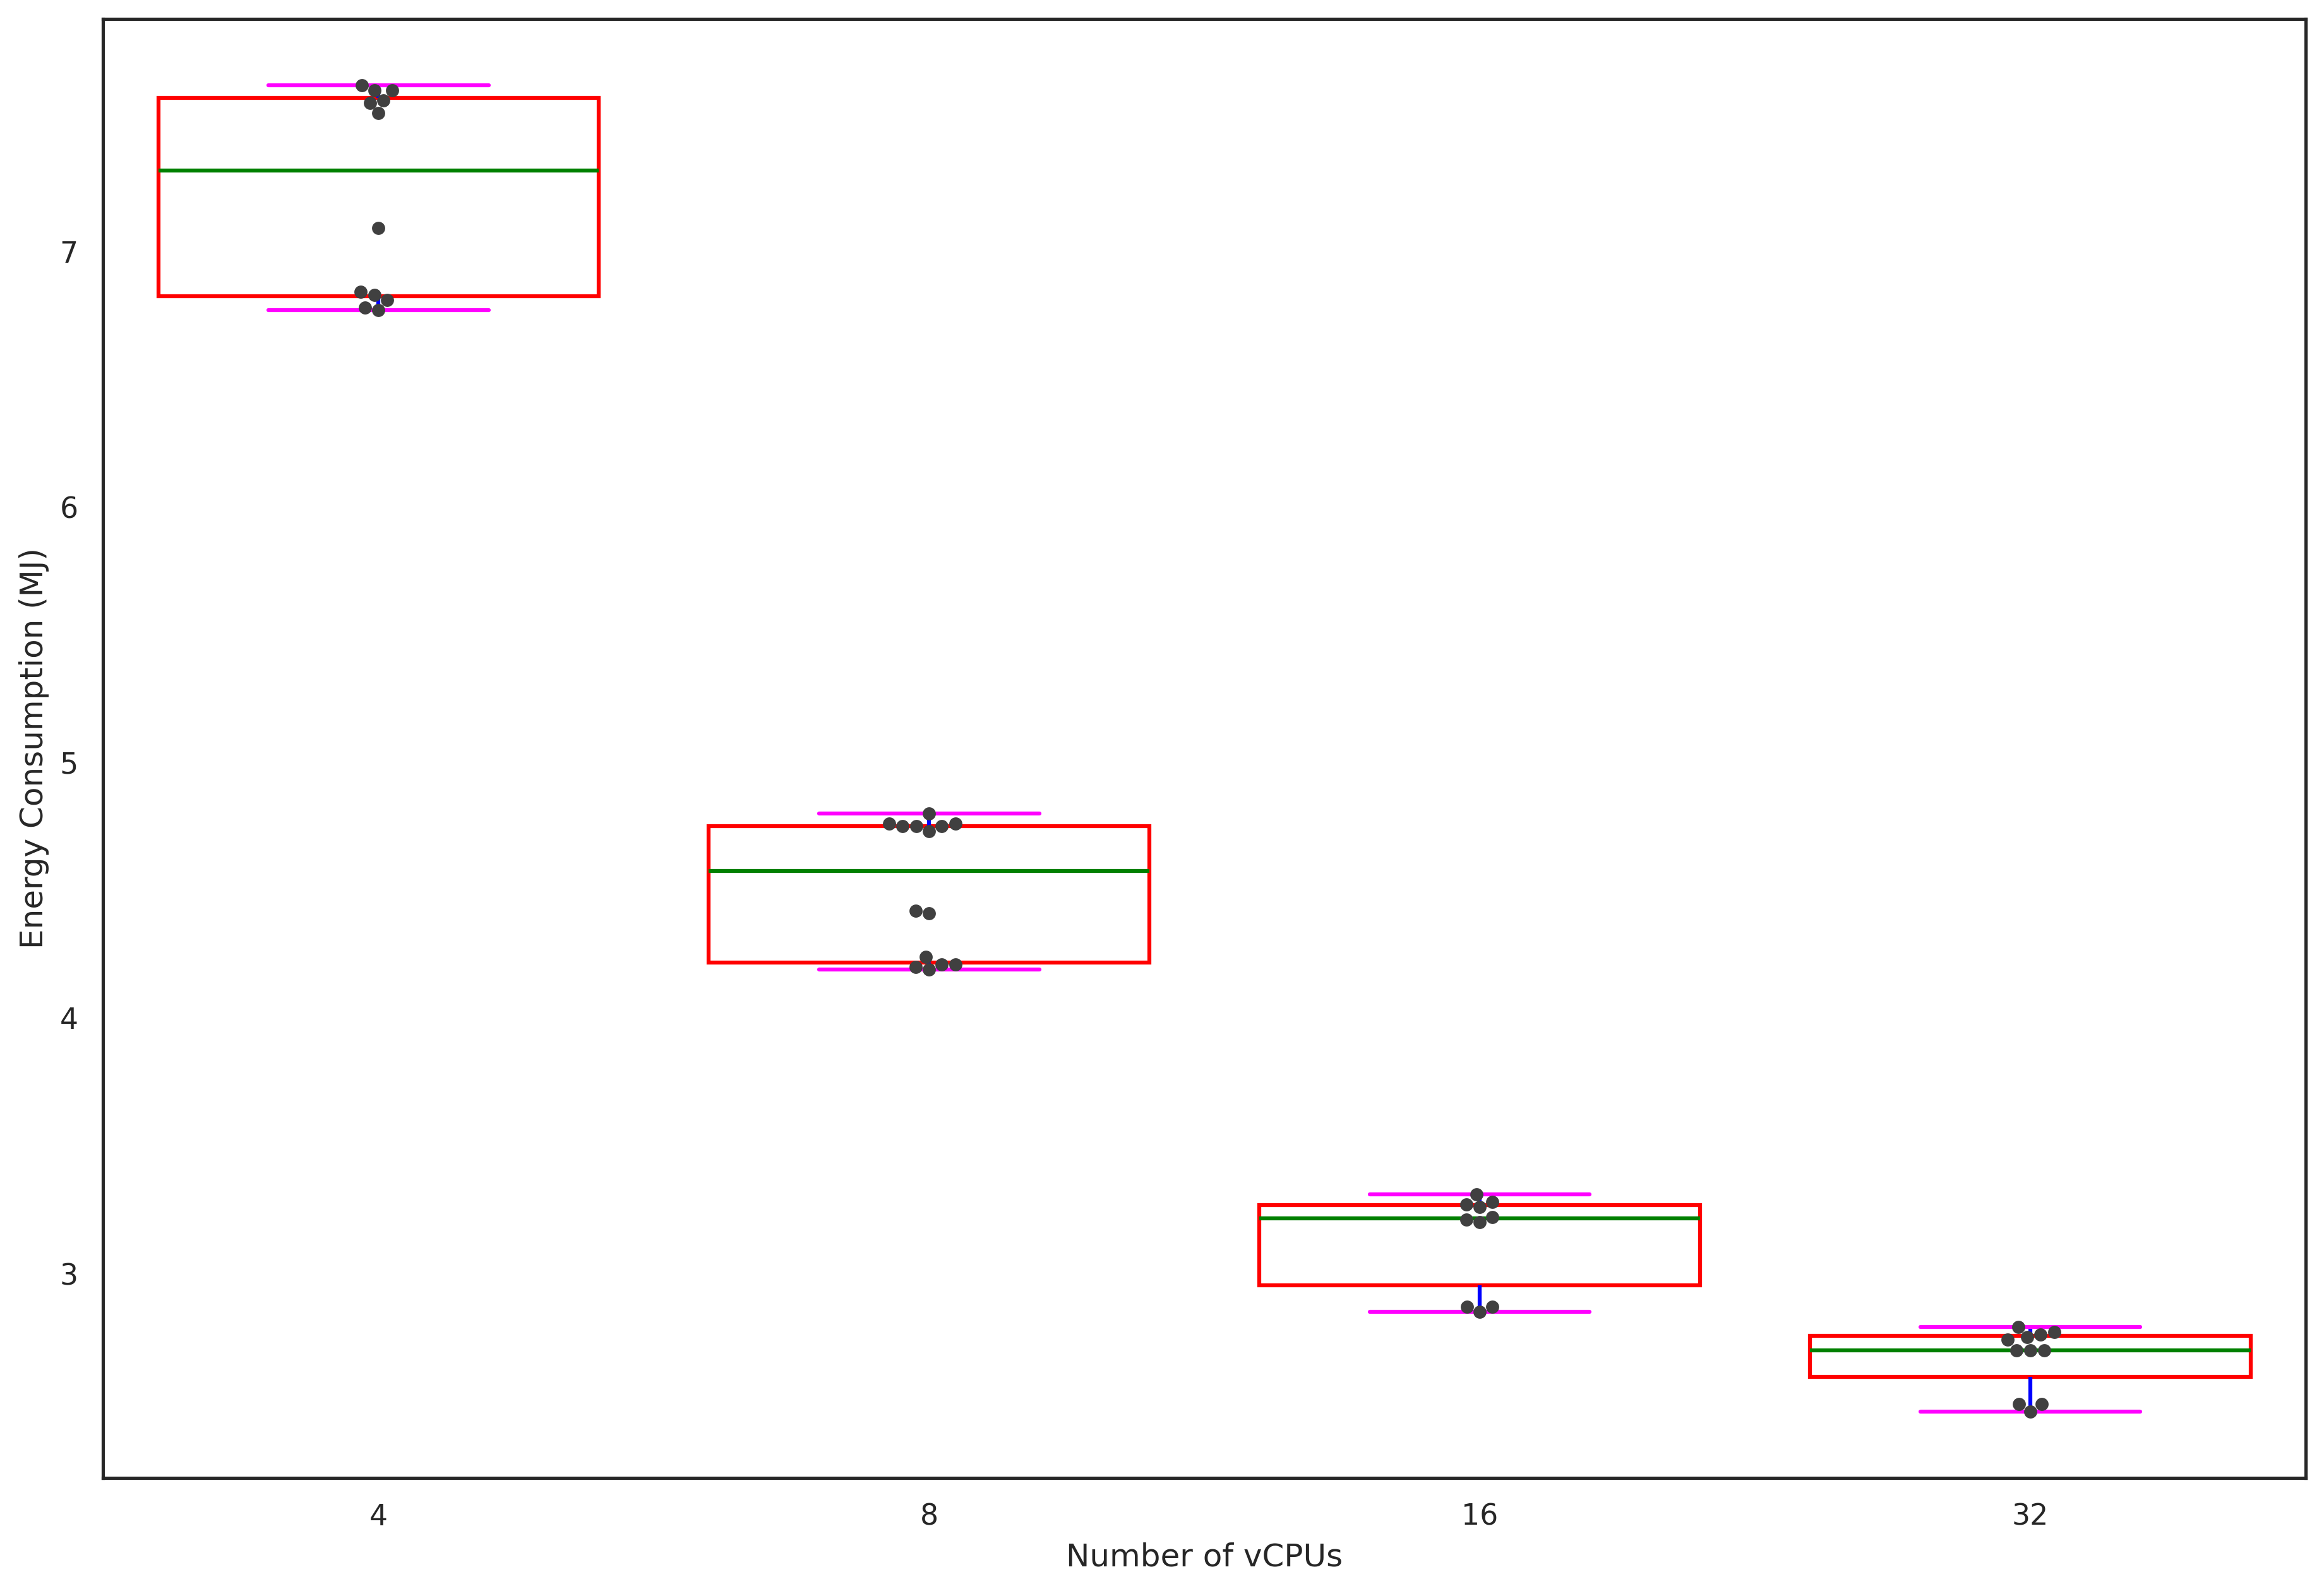

In [25]:
da.show_boxplot(
    daa_energy, "Energy Consumption of DAA Workflow at Varying Parallelism Degrees",
    x_label="Number of vCPUs", y_label="Energy Consumption (MJ)", store=True
)

## Normality Test: Shapiro-Wilk and QQ-Plots

In [26]:
normality = ps.test_normality(daa_energy)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.719283  0.000018
1      8  0.694140  0.000002
2     16  0.653038  0.000011
3     32  0.643806  0.000004


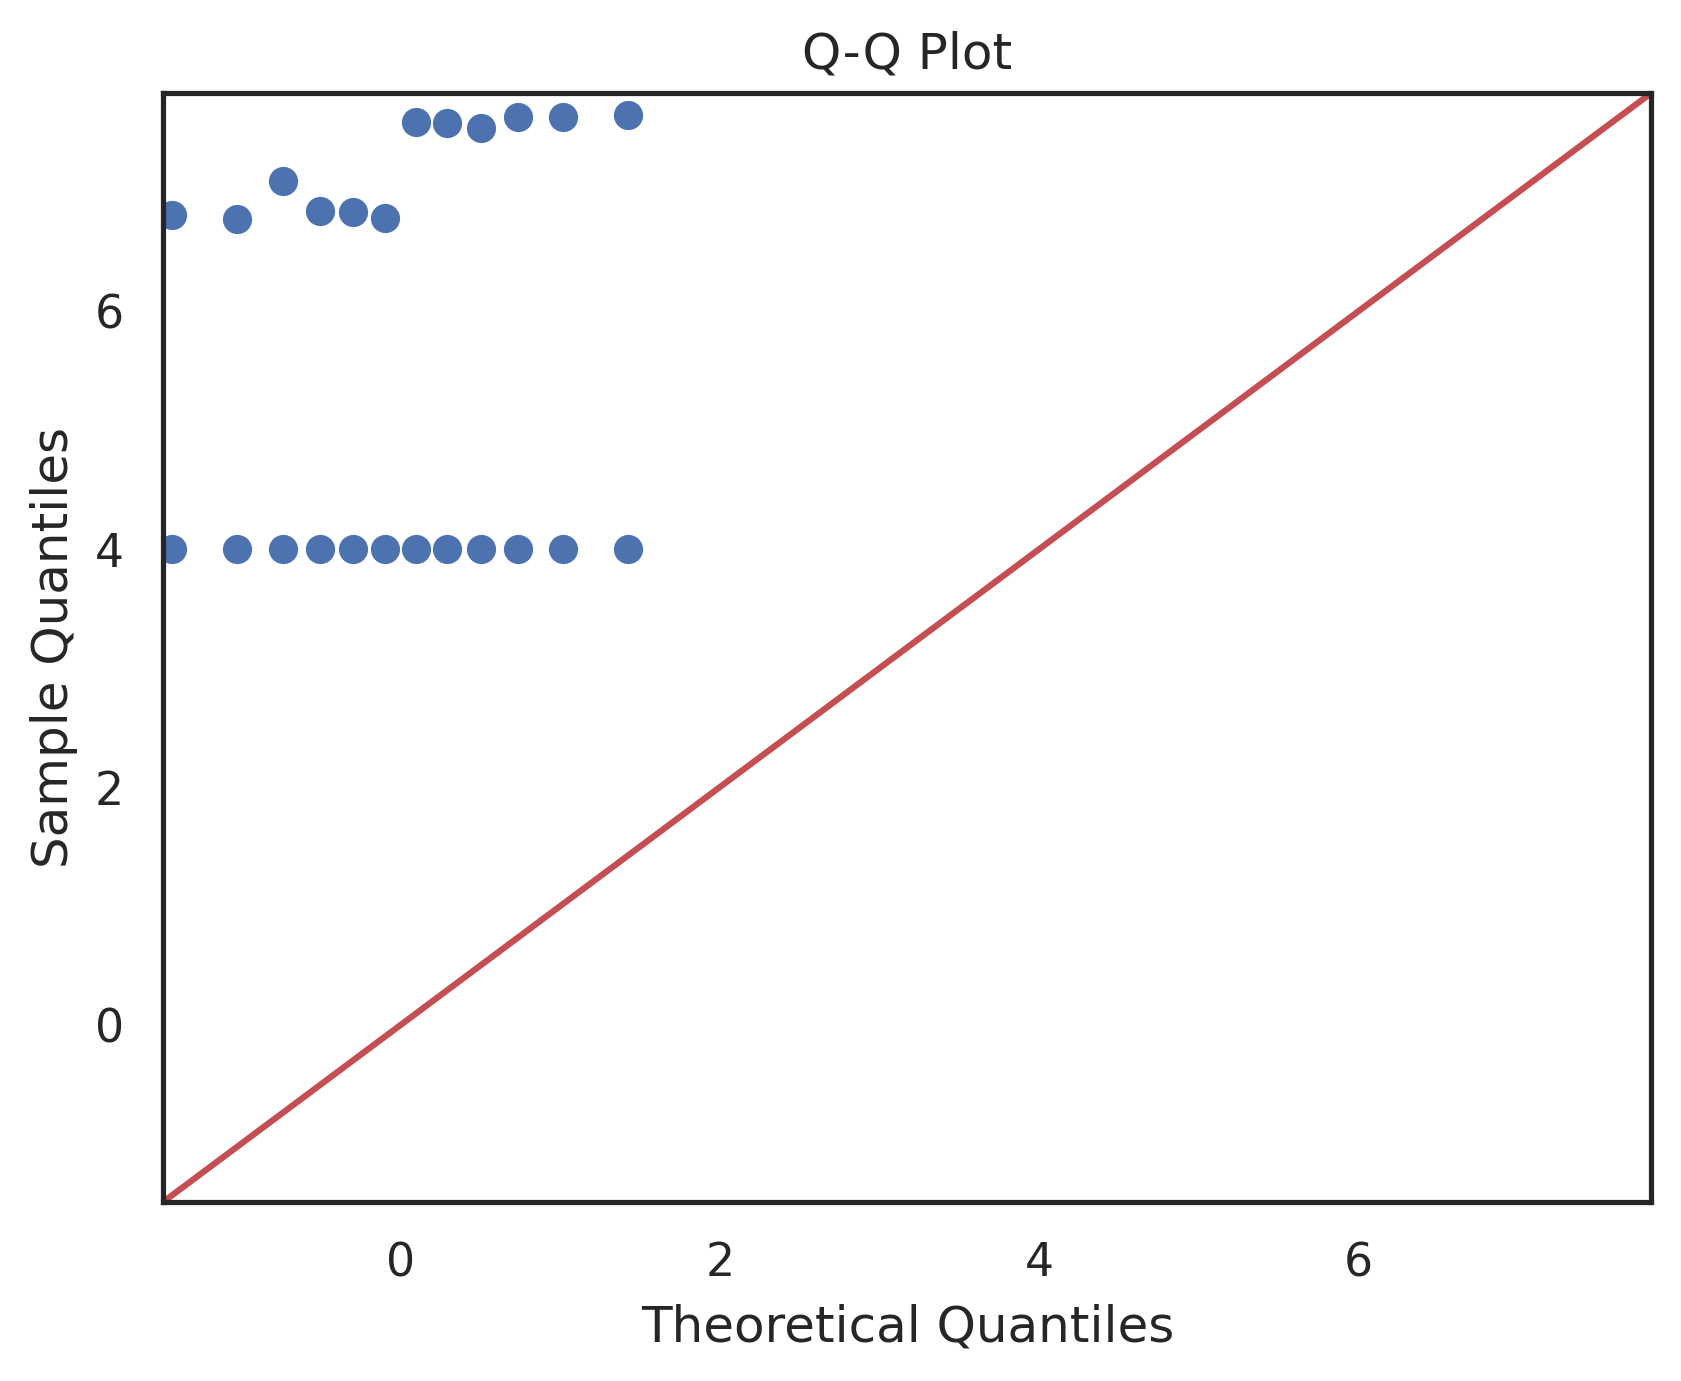

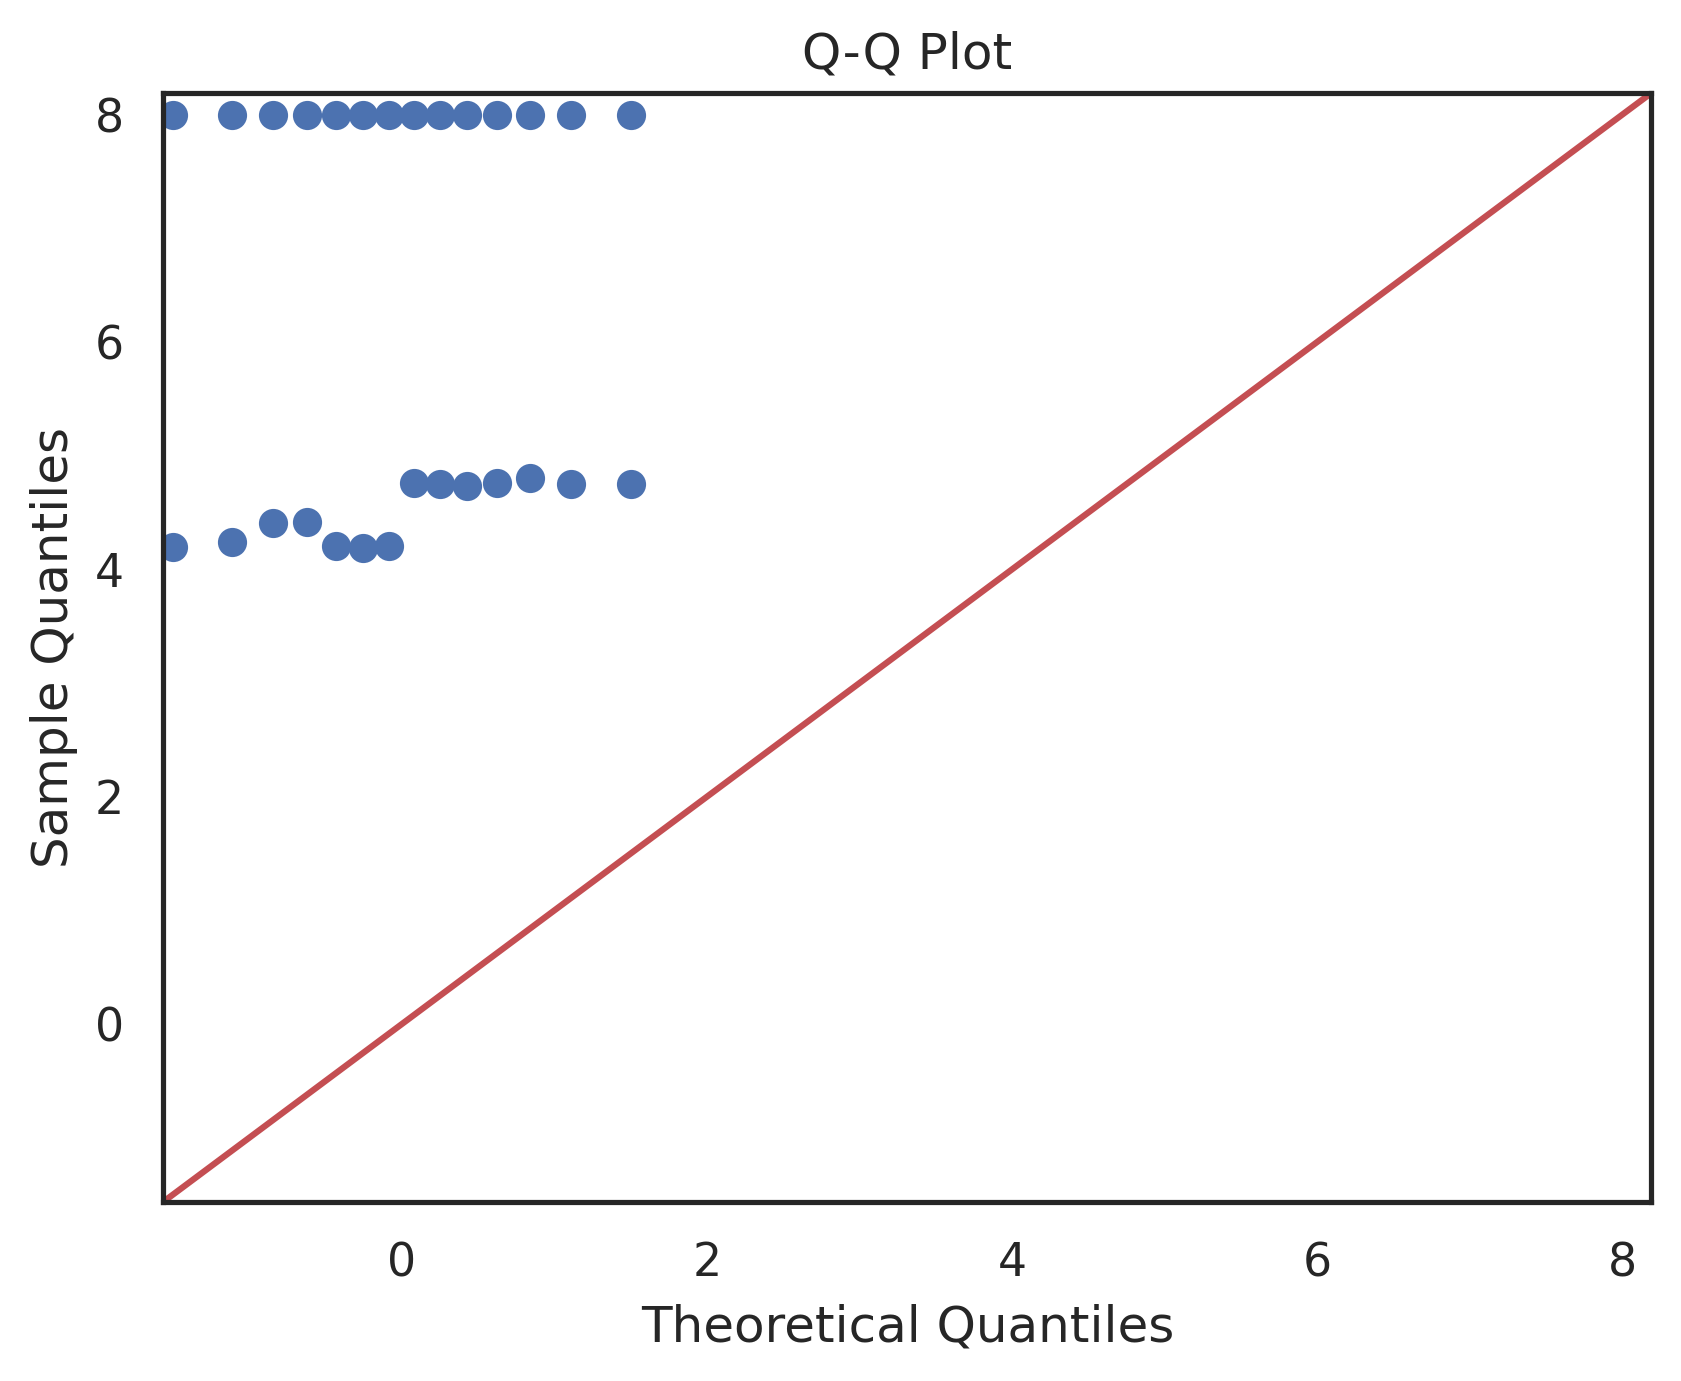

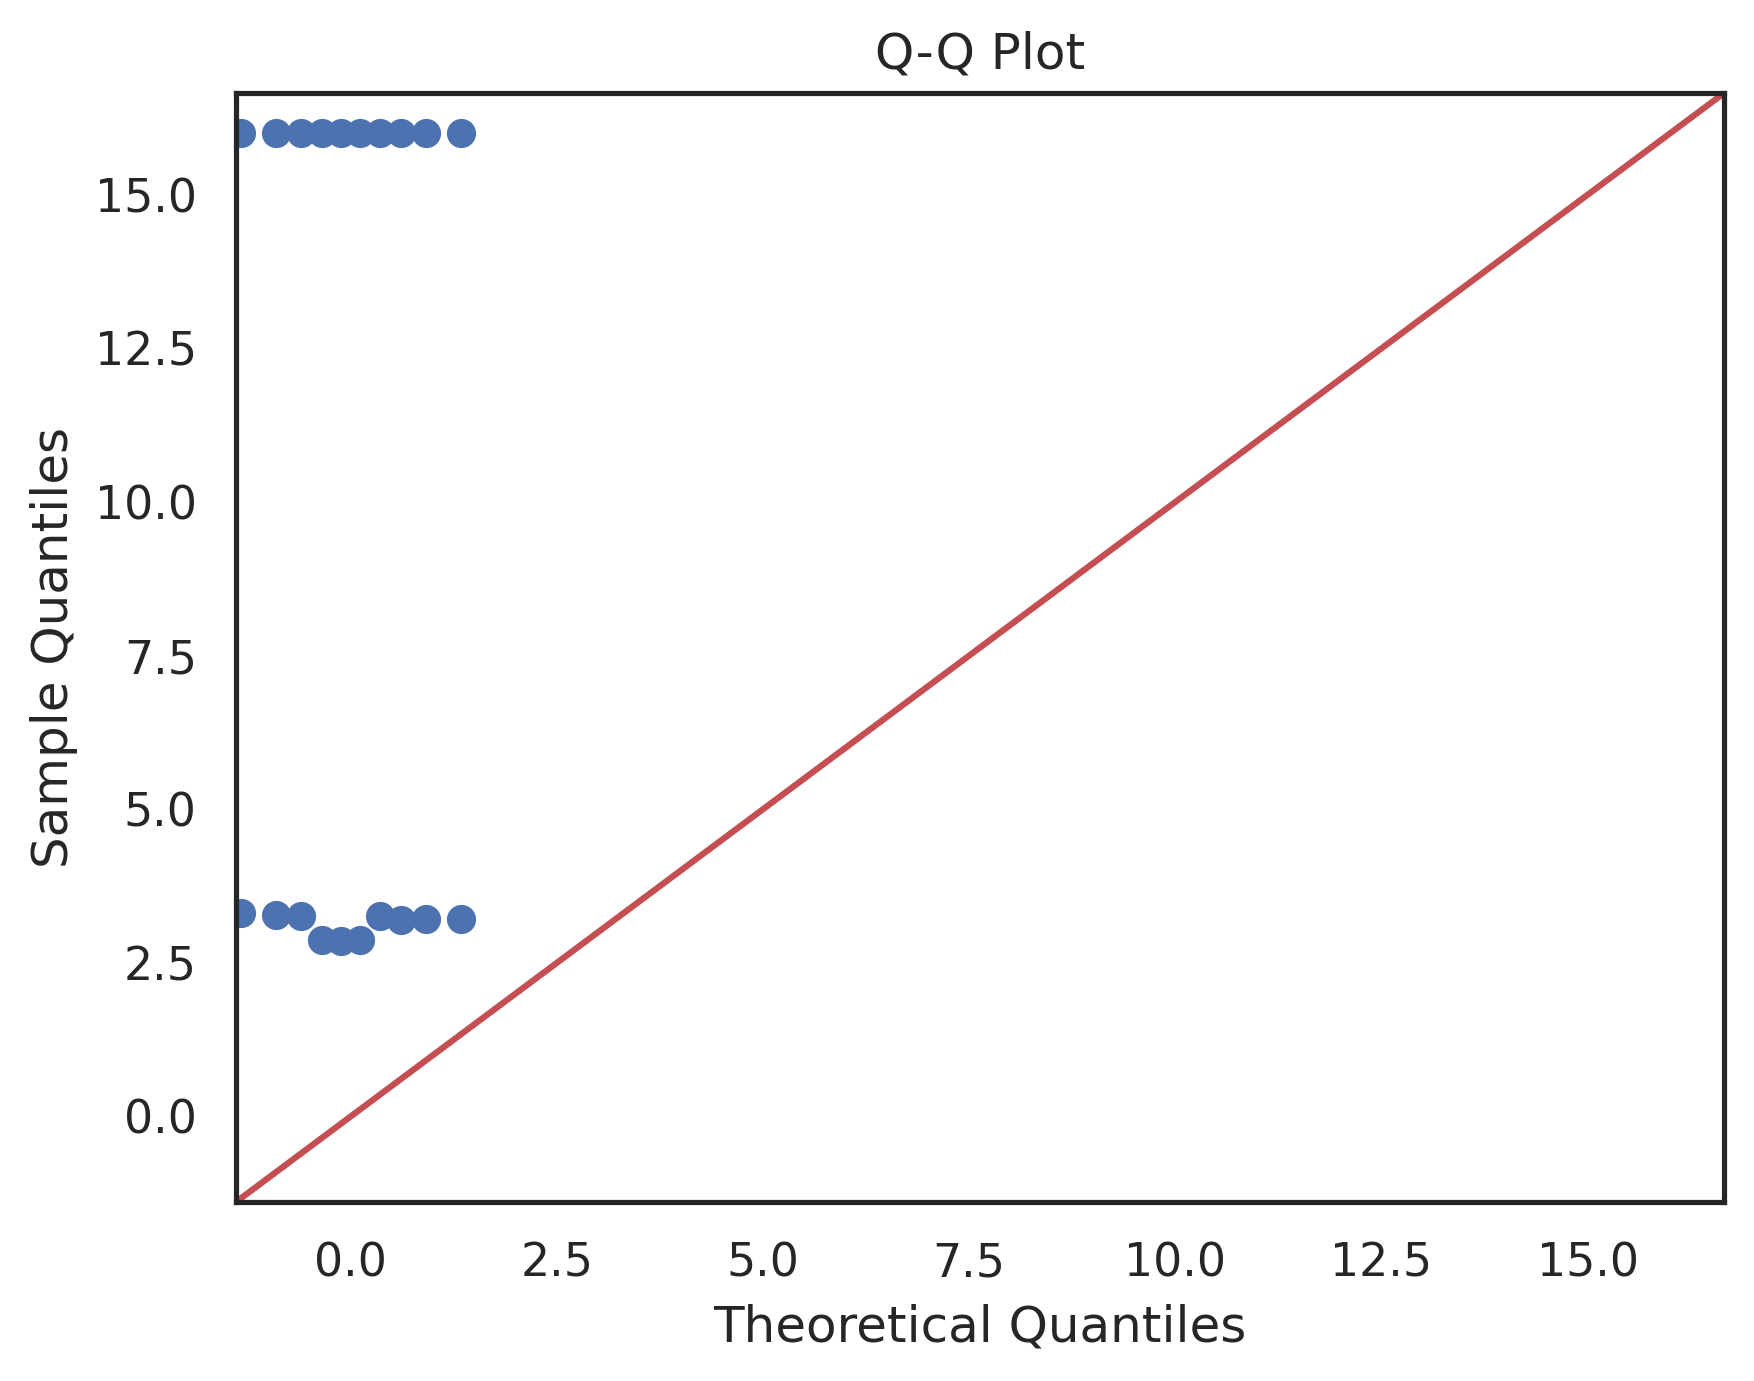

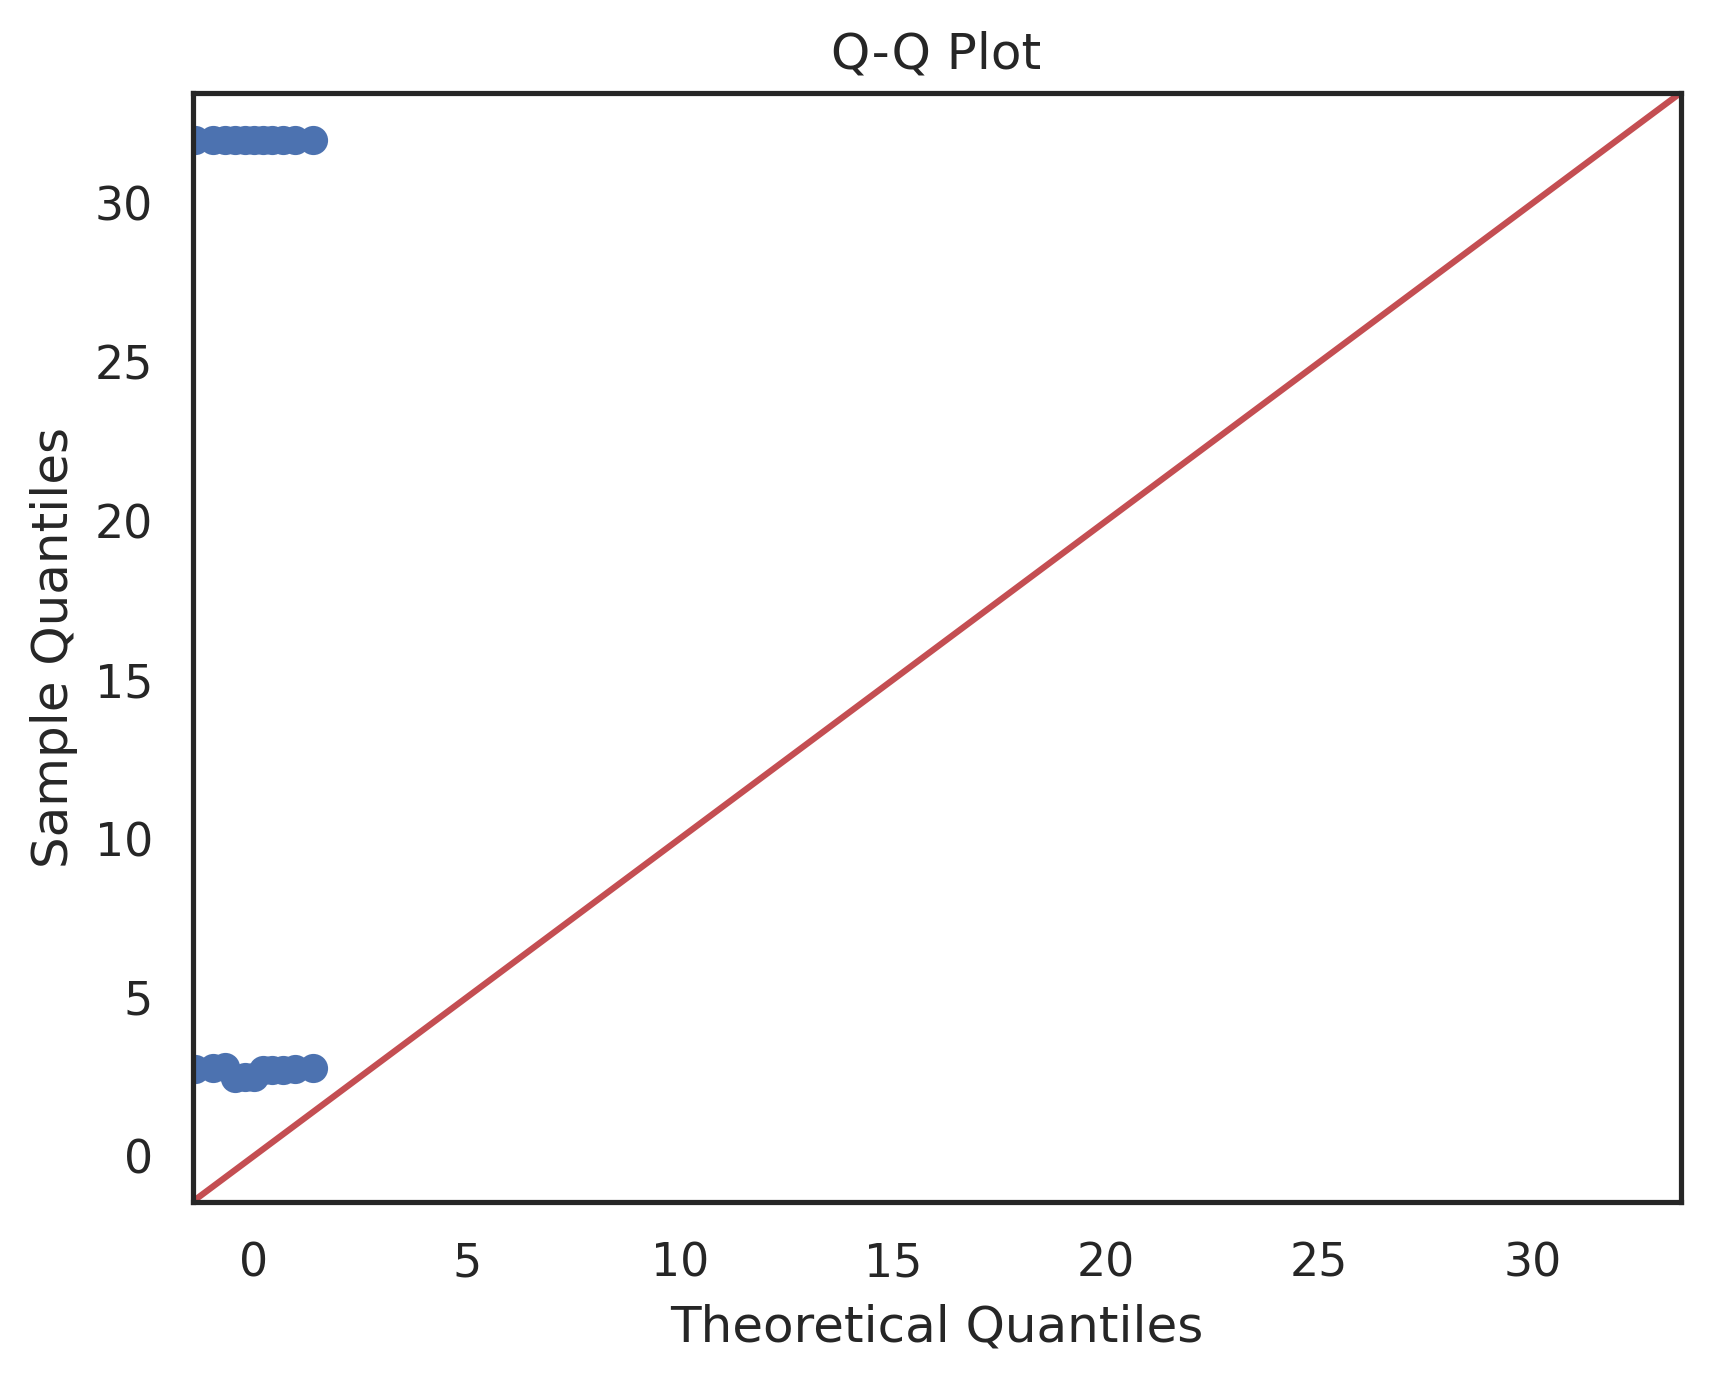

In [27]:
ps.generate_qq(daa_energy)

## Hypothesis Testing: Kruskal-Wallis

In [28]:
ps.test_hypothesis_kruskal(daa_energy)

(43.037667071688944, 2.4160978155904095e-09)

## Effect Size: Cliff's Delta

In [39]:
ps.calc_cliffs_delta(daa_energy)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",1.0,large
1,"(8, 16)",1.0,large
2,"(16, 32)",1.0,large


In [46]:
## Effect Size: Percentage Improvement

In [45]:
ps.calc_groups_improvement(daa_energy)

,CPU-GROUPS,Mean Improvment,Median Improvent,Mean Delta,Median Delta
0,"(4, 8)",60.171995,59.890710,2.715476,2.740
1,"(8, 16)",43.996718,42.301711,1.378857,1.360
2,"(16, 32)",17.458262,19.074074,0.465818,0.515
3,"(4, 32)",170.908575,170.925926,4.560152,4.615
